  0%|          | 0/232 [00:00<?, ?it/s]

  0%|          | 0/232 [00:00<?, ?it/s]

232
['9.36+-0.31', '9.94+-0.17', '10.47+-0.27']
['0.98+-0.10', '1.25+-0.10', 'nan+-nan']


/u/yacheng/conda-envs/test/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3858: RuntimeWarning: Mean of empty slice.
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/u/yacheng/conda-envs/test/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/u/yacheng/conda-envs/test/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/u/yacheng/conda-envs/test/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/u/yacheng/conda-envs/test/lib/python3.13/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


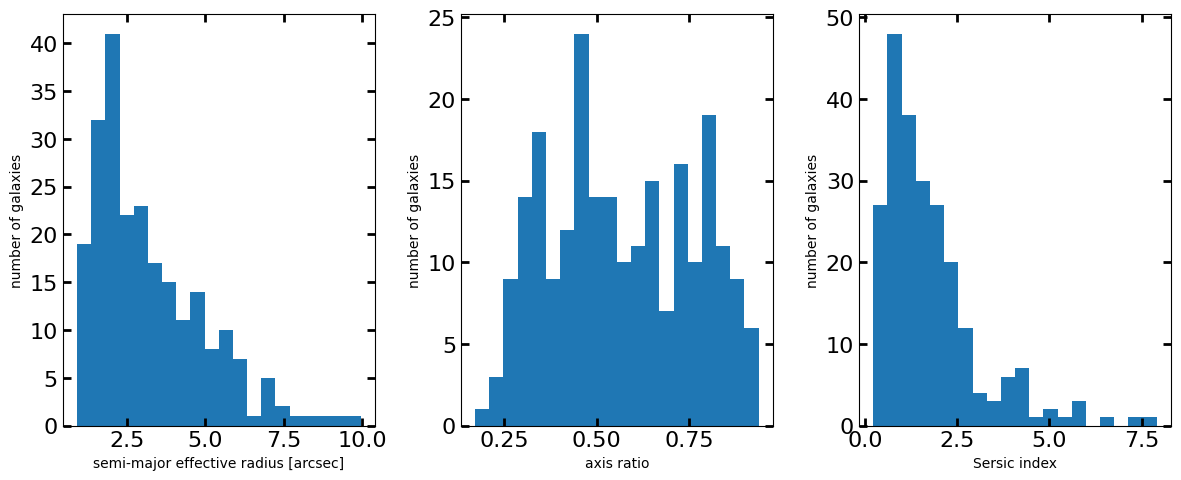

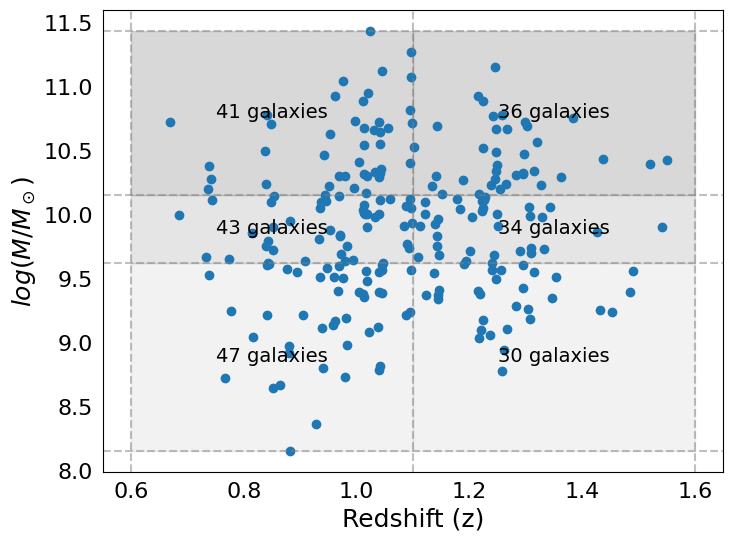

In [1]:
import  os
import  time
from    tqdm.auto           import tqdm
import  numpy               as     np
from    astropy.io          import fits
from    astropy.cosmology   import Planck18
import  astropy.units       as     u
from    scipy.constants     import arcsec
from    astropy.table       import Table
import  matplotlib.pyplot   as     plt
from    matplotlib.gridspec import GridSpec
from    utils.colors        import color1, color2, color3, color4
from    utils.hst3d         import *
from    utils.jwst          import *
from    utils.tool_analysis import K_lambda, calculate_attenuation_err_from_ratio, calculate_attenuation_from_ratio, log10_flux_err, list_flatten

obj_lis = Table.read('selected_objects.fits')

# Create mass bins with equal number of galaxies m   
sorted_masses = np.sort(np.log10(obj_lis['mass']))
bins_m = [sorted_masses[0], sorted_masses[len(sorted_masses) // 3], sorted_masses[2 * len(sorted_masses) // 3], sorted_masses[-1]]

# Create labels for the mass bins based on actual bin edges
bin_label_m = [rf'${bins_m[i]:.1f}<\log M/M_\odot<{bins_m[i+1]:.1f}$' for i in range(len(bins_m) - 1)]
binning_m = np.digitize(np.log10(obj_lis['mass']),bins_m)

bins_z  = [-np.inf,1.1,np.inf]
binning_z = np.digitize(obj_lis['z_MAP'],bins_z)
# Keep the dynamically generated bin_label_m instead of overwriting with hardcoded values
bin_label_z = ['0.7<z<1.1','1.1<z<1.5']

obj_lis['bin_m'] = binning_m
obj_lis['bin_z'] = binning_z
obj_lis.write('obj_lis_selected_bins.fits',overwrite=True)

#move all objects from diagnostic_plot_all to diagnostic_plot_selected 
src_folder = 'output/plots/diagnostic_plot_all'
dst_folder = 'output/plots/diagnostic_plot_selected'
#delete previous output folder if exist
if os.path.exists(dst_folder):
    #remove the folder and its contents
    os.system(f'rm -rf {dst_folder}')
os.makedirs(dst_folder, exist_ok=True)
for i, obj in enumerate(tqdm(obj_lis)):
    file = f"{obj['subfield'].lower()}_{str(obj['id']).zfill(5)}.png"
    src_file = f"{src_folder}/{file}"
    dst_file = f"{dst_folder}/{file}"
    
    # Copy the file to the new folder
    if os.path.exists(src_file):
        os.system(f'cp {src_file} {dst_file}')

#delete previous output folders if exist
for folder in ['output/plots/low_mass', 'output/plots/mid_mass', 'output/plots/high_mass']:
    if os.path.exists(folder):
        #remove the folder and its contents
        os.system(f'rm -rf {folder}')
    os.makedirs(folder, exist_ok=True)
    
for i, obj in enumerate(tqdm(obj_lis)):
    mass = np.log10(obj['mass'])
    if mass < bins_m[1]:
        folder = 'output/plots/low_mass'
    elif mass < bins_m[2]:
        folder = 'output/plots/mid_mass'
    else:
        folder = 'output/plots/high_mass'
        
    file = f"{obj['subfield'].lower()}_{str(obj['id']).zfill(5)}.png"
    src_file = f"output/plots/diagnostic_plot_selected/{file}"
    dst_file = f"{folder}/{file}"
    
    # Copy the file to the appropriate folder
    if os.path.exists(src_file):
        os.system(f'cp {src_file} {dst_file}')

print(len(obj_lis))
#print obj with 


std_lis = [np.log10(np.median(obj_lis['mass'][binning_m==i])) for i in range(1,4)]
std_lis_var = [np.std(np.log10(obj_lis['mass'][binning_m==i])) for i in range(1,4)]
print([f'{std_lis[i]:.2f}+-{std_lis_var[i]:.2f}' for i in range(3)])


#check the properties for mass and 
std_lis = [np.median(obj_lis['z_MAP'][binning_z==i]) for i in range(1,4)]
std_lis_var = [np.std(obj_lis['z_MAP'][binning_z==i]) for i in range(1,4)]
print([f'{std_lis[i]:.2f}+-{std_lis_var[i]:.2f}' for i in range(3)])

3*np.median(obj_lis['re'])/0.1* np.median(obj_lis['pixel_length'])

fig, ax = plt.subplots(1, 3, figsize=(12, 5))
#make general fonts bigger
plt.rcParams.update({'font.size': 13})
#hist effective radius ['re']
ax[0].hist(np.array(obj_lis['re']/0.1), bins=20)
ax[0].set_xlabel('semi-major effective radius [arcsec]')
ax[0].set_ylabel('number of galaxies')
ax[0].tick_params(direction='in', which='both', top=True, right=True, width=2, length=6,labelsize=16)  # Set tick width and length

#hist axis ratio ['q']
ax[1].hist(np.array(obj_lis['q']), bins=20)
ax[1].set_xlabel('axis ratio')
ax[1].set_ylabel('number of galaxies')
ax[1].tick_params(direction='in', which='both', top=True, right=True, width=2, length=6,labelsize=16)  # Set tick width and length

ax[2].hist(np.array(obj_lis['n']), bins=20)
ax[2].set_xlabel('Sersic index')
ax[2].set_ylabel('number of galaxies')
ax[2].tick_params(direction='in', which='both', top=True, right=True, width=2, length=6,labelsize=16)  # Set tick width and length

plt.tight_layout()
plt.savefig('morph.jpg')
plt.show()

# Define the bin edges for mass and redshift
mass_bins = bins_m
redshift_bins = [0.6, 1.1, 1.6]

fit = plt.figure(figsize=(8, 6))
# Plot the data points
plt.plot(obj_lis['z_MAP'], np.log10(obj_lis['mass']), 'o')

# Add vertical lines for redshift bins
for z in redshift_bins:
    plt.axvline(z, color='grey', linestyle='--', alpha=0.5)

# Add horizontal lines for mass bins
for m in mass_bins:
    plt.axhline(m, color='grey', linestyle='--', alpha=0.5)

# Add shaded regions for each bin and annotate the number of data points
for i in range(len(redshift_bins) - 1):
    for j in range(len(mass_bins) - 1):
        bin_mask = (obj_lis['z_MAP'] >= redshift_bins[i]) & (obj_lis['z_MAP'] < redshift_bins[i + 1]) & (np.log10(obj_lis['mass']) >= mass_bins[j]) & (np.log10(obj_lis['mass']) < mass_bins[j + 1])
        num_points = np.sum(bin_mask)
        plt.fill_betweenx([mass_bins[j], mass_bins[j + 1]], redshift_bins[i], redshift_bins[i + 1], color='grey', alpha=0.1 * (j + 1))
        plt.text((redshift_bins[i] + redshift_bins[i + 1]) / 2, (mass_bins[j] + mass_bins[j + 1]) / 2, f'{num_points} galaxies', color='black', ha='center', va='center', fontsize=14)
#display no tick lines in the plot
plt.tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=True, labelleft=True)
#make x,y axis lablel big
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
#plt.ylim(8.0, 11.2)
#plt.xlim(0.55, 1.6)
plt.xlabel('Redshift (z)', fontsize=18)
plt.ylabel(r'$log(M/M_\odot)$', fontsize=18)
#plt.savefig('image_outputs/mass_redshift_bins.png')
plt.show()

# extract all radial profiles from the whole sample + radius binning

In [ ]:

#extract all usefull data in different mass bins
r_kpc_lis = [[], [], []]
r_reff_lis = [[], [], []]
ha_lis_all = [[], [], []]; ha_err_lis_all = [[], [], []]
ha_corr_lis_all = [[], [], []]; ha_corr_err_lis_all = [[], [], []]
balmer_kpc_all = [[], [], []]; balmer_kpc_err_all = [[], [], []]
balmer_reff_all = [[], [], []]; balmer_reff_err_all = [[], [], []]
alpha_values = [[], [], []]

#median effective radius in kpc
median_reff_kpc = np.mean(obj_lis['re']) * arcsec * Planck18.angular_diameter_distance(np.median(obj_lis['z_MAP'])).to(u.kpc).value

for i in range(3):
    for obj in tqdm(obj_lis[binning_m==i+1]):
        r_kpc = obj['distance']/0.1*obj['pixel_length']
        r_reff = obj['distance']/obj['re']
        ha = obj['ha']; ha_err = obj['ha_err']; ha_limit=obj['ha_limit']
        hb = obj['hb']; hb_err = obj['hb_err']; hb_limit=obj['hb_limit']
        balmer = obj['balmer']; balmer_err = obj['balmer_err']
        A_ha_err = calculate_attenuation_err_from_ratio(balmer, balmer_err)
        
        mask_valid = (ha>np.sqrt(ha_err**2 + ha_limit**2)) & (hb>np.sqrt(hb_err**2 + hb_limit**2))
        #only look at data above detection limit within 3 times of the median effective radius in kpc
        #mask_for_kpc =  (r_kpc < 3*median_reff_kpc) & mask_valid 
        mask_for_re  =  (r_reff < 2.1) & mask_valid & (r_kpc < 3*median_reff_kpc)
        mask_for_kpc = mask_for_re
        
        if  r_kpc[mask_for_kpc][-1] > 9:
            print(obj['id'],obj['field'])
        
        if np.any(calculate_attenuation_from_ratio(balmer[mask_for_re]) < -2):
            print(f"{obj['subfield']}_{obj['id']}")
        
        ha = ha*1e-15  #convert to erg/s/cm2/arcsec2
        ha = ha * 4*np.pi* (Planck18.luminosity_distance(obj['z_MAP']).to(u.cm).value)**2
        #now ha in erg/s/arcsec^2
        #convert from observed ha sb to absolute ha surface brightness
        #convert to erg/s/kpc^2, 0.1 arcsec/pixel
        ha = ha * 0.1**2 / obj['pixel_length']**2 
        ha_err = ha_err * 1e-15 * 4*np.pi * (Planck18.luminosity_distance(obj['z_MAP']).to(u.cm).value)**2 * 0.1**2 / obj['pixel_length']**2 
        ha_corr = ha * 10**(obj['A_ha']*0.4)  #dust corrected ha luminosity surface density in erg/s/kpc^2
        ha_corr_err = np.sqrt((ha_err * 10**(obj['A_ha']*0.4))**2 + (ha * 10**(obj['A_ha']*0.4) * 0.4 * np.log(10) * A_ha_err)**2)
        
        
        alpha_lis = []        
        sigma_ha = (ha/np.sqrt(ha_err**2 + ha_limit**2))
        sigma_hb = (hb/np.sqrt(hb_err**2 + hb_limit**2))
        for sigma_ha_i, sigma_hb_i in zip(sigma_ha[mask_for_re], sigma_hb[mask_for_re]):
            if sigma_ha_i>2 and sigma_hb_i>2:
                alpha_lis.append(True)
            else:
                alpha_lis.append(False)
        alpha_values[i].append(alpha_lis)

        #append data to the list
        r_kpc_lis[i].append(r_kpc[mask_for_kpc].tolist())
        r_reff_lis[i].append(r_reff[mask_for_re].tolist())
        
        balmer_kpc_all[i].append(balmer[mask_for_kpc].tolist())
        balmer_kpc_err_all[i].append(balmer_err[mask_for_kpc].tolist())
        
        balmer_reff_all[i].append(balmer[mask_for_re].tolist())
        balmer_reff_err_all[i].append(balmer_err[mask_for_re].tolist())
        
        ha_lis_all[i].append(np.log10(ha[mask_for_re]).tolist())
        ha_err_lis_all[i].append((0.4343*ha_err[mask_for_re]/ha[mask_for_re]).tolist())
        ha_corr_lis_all[i].append(np.log10(ha_corr[mask_for_re]).tolist())
        ha_corr_err_lis_all[i].append((0.4343*ha_corr_err[mask_for_re]/ha_corr[mask_for_re]).tolist())

#radius binning based on kpc radius
#trace everythin within 3 times of median effective radius
r_lim = 3*median_reff_kpc
#use median redshift to compute median_pixel_length of each mass bin in kpc
median_pixel_length_kpc = 0.1 * arcsec * Planck18.angular_diameter_distance(np.median(obj_lis['z_MAP'])).to(u.kpc).value
#number of bins from 0 to 3 times of median effective radius in kpc
num_bins = r_lim // median_pixel_length_kpc
bin_edges_kpc  = np.linspace(0, median_pixel_length_kpc*num_bins, int(num_bins)+1)


#radius binning based on effective radius
bin_edges_reff = np.linspace(0, 2.1, 6)
bin_edges_ha   = np.linspace(0,2.1,6)

#radius bin centers for plotting
r_bin_kpc_lis =bin_edges_kpc[:-1]+np.diff(bin_edges_kpc)/2.
r_bin_reff_lis = bin_edges_reff[:-1]+np.diff(bin_edges_reff)/2.
r_bin_ha_lis = bin_edges_ha[:-1]+np.diff(bin_edges_ha)/2.

#initialize mean and std lists
bd_kpc_lis, bd_kpc_err_lis,  std_kpc_lis,  sint_kpc_lis  = [[],[],[]], [[],[],[]], [[],[],[]], [[],[],[]]
bd_reff_lis, bd_reff_err_lis, std_reff_lis, sint_reff_lis = [[],[],[]], [[],[],[]], [[],[],[]], [[],[],[]]

ha_mean_lis,      ha_mean_err_lis,      std_ha_lis,      sint_ha_lis       = [[],[],[]], [[],[],[]], [[],[],[]], [[],[],[]]
ha_corr_mean_lis, ha_corr_mean_err_lis, std_ha_corr_lis, sint_ha_corr_lis  = [[],[],[]], [[],[],[]], [[],[],[]], [[],[],[]]

#initialize high sigma (high quality) mean and std lists
bd_kpc_lis_hsigma, bd_kpc_err_lis_hsigma, std_kpc_lis_hsigma = [[],[],[]], [[],[],[]], [[],[],[]]
bd_reff_lis_hsigma, bd_reff_err_lis_hsigma, std_reff_lis_hsigma = [[],[],[]], [[],[],[]], [[],[],[]]

ha_mean_lis_hsigma, ha_mean_err_lis_hsigma, std_ha_lis_hsigma = [[],[],[]], [[],[],[]], [[],[],[]]
ha_corr_mean_lis_hsigma, ha_corr_mean_err_lis_hsigma, std_ha_corr_lis_hsigma = [[],[],[]], [[],[],[]], [[],[],[]]

#loop over 3 mass bins
for i in range(3):
    #flatten alpha_values for masking high quality data
    alpha_flat = np.array(list_flatten(alpha_values[i]))
    
    #the kpc binning
    bin_indices_kpc = np.digitize(list_flatten(r_kpc_lis[i]), bin_edges_kpc)-1
    for j in range(len(bin_edges_kpc)-1):
        values_for_binning = np.array(list_flatten(balmer_kpc_all[i]))
        values_err_for_binning = np.array(list_flatten(balmer_kpc_err_all[i]))
        bin_mask = bin_indices_kpc == j
        if np.sum(bin_mask) > 2:
            bd_kpc_lis[i].append(np.mean(values_for_binning[bin_mask]))
            bd_kpc_err_lis[i].append(np.mean(values_err_for_binning[bin_mask]))
            std_kpc_lis[i].append(np.std(values_for_binning[bin_mask]))
        else:
            bd_kpc_lis[i].append(np.nan)
            bd_kpc_err_lis[i].append(np.nan)
            std_kpc_lis[i].append(np.nan)
        
        #high sigma (high quality) binning
        bin_mask_hsigma = bin_mask & alpha_flat
        if np.sum(bin_mask_hsigma) > 2:
            bd_kpc_lis_hsigma[i].append(np.mean(values_for_binning[bin_mask_hsigma]))
            bd_kpc_err_lis_hsigma[i].append(np.mean(values_err_for_binning[bin_mask_hsigma]))
            std_kpc_lis_hsigma[i].append(np.std(values_for_binning[bin_mask_hsigma]))
        else:
            bd_kpc_lis_hsigma[i].append(np.nan)
            bd_kpc_err_lis_hsigma[i].append(np.nan)
            std_kpc_lis_hsigma[i].append(np.nan)
            
    #the reff binning
    bin_indices_reff = np.digitize(list_flatten(r_reff_lis[i]), bin_edges_reff)-1
    for j in range(len(bin_edges_reff)-1):
        values_for_binning = np.array(list_flatten(balmer_reff_all[i]))
        values_err_for_binning = np.array(list_flatten(balmer_reff_err_all[i]))
        bin_mask = bin_indices_reff == j
        if np.sum(bin_mask) > 2:
            bd_reff_lis[i].append(np.mean(values_for_binning[bin_mask]))
            bd_reff_err_lis[i].append(np.mean(values_err_for_binning[bin_mask]))
            std_reff_lis[i].append(np.std(values_for_binning[bin_mask]))
        else:
            bd_reff_lis[i].append(np.nan)
            bd_reff_err_lis[i].append(np.nan)
            std_reff_lis[i].append(np.nan)
        
        #high sigma (high quality) binning
        bin_mask_hsigma = bin_mask & alpha_flat
        if np.sum(bin_mask_hsigma) > 2:
            bd_reff_lis_hsigma[i].append(np.mean(values_for_binning[bin_mask_hsigma]))
            bd_reff_err_lis_hsigma[i].append(np.mean(values_err_for_binning[bin_mask_hsigma]))
            std_reff_lis_hsigma[i].append(np.std(values_for_binning[bin_mask_hsigma]))
        else:
            bd_reff_lis_hsigma[i].append(np.nan)
            bd_reff_err_lis_hsigma[i].append(np.nan)
            std_reff_lis_hsigma[i].append(np.nan)
            
            
    #the ha binning
    bin_indices_ha = np.digitize(list_flatten(r_reff_lis[i]), bin_edges_ha)-1
    for j in range(len(bin_edges_ha)-1):
        bin_mask = bin_indices_ha == j
        values_for_binning = np.array(list_flatten(ha_lis_all[i]))
        values_err_for_binning = np.array(list_flatten(ha_err_lis_all[i]))
        values_for_binning_corr = np.array(list_flatten(ha_corr_lis_all[i]))
        values_err_for_binning_corr = np.array(list_flatten(ha_corr_err_lis_all[i]))
        
        if np.sum(bin_mask) > 2:
            ha_mean_lis[i].append(np.mean(values_for_binning[bin_mask]))
            ha_mean_err_lis[i].append(np.mean(values_err_for_binning[bin_mask]))
            std_ha_lis[i].append(np.std(values_for_binning[bin_mask]))

            ha_corr_mean_lis[i].append(np.mean(values_for_binning_corr[bin_mask]))
            ha_corr_mean_err_lis[i].append(np.mean(values_err_for_binning_corr[bin_mask]))
            std_ha_corr_lis[i].append(np.std(values_for_binning_corr[bin_mask]))

        else:
            ha_mean_lis[i].append(np.nan)
            ha_mean_err_lis[i].append(np.nan)
            std_ha_lis[i].append(np.nan)
            ha_corr_mean_lis[i].append(np.nan)
            ha_corr_mean_err_lis[i].append(np.nan)
            std_ha_corr_lis[i].append(np.nan)
        
        #high sigma (high quality) binning
        bin_mask_hsigma = bin_mask & alpha_flat
        if np.sum(bin_mask_hsigma) > 2:
            ha_mean_lis_hsigma[i].append(np.mean(values_for_binning[bin_mask_hsigma]))
            ha_mean_err_lis_hsigma[i].append(np.mean(values_err_for_binning[bin_mask_hsigma]))
            std_ha_lis_hsigma[i].append(np.std(values_for_binning[bin_mask_hsigma]))

            ha_corr_mean_lis_hsigma[i].append(np.mean(values_for_binning_corr[bin_mask_hsigma]))
            ha_corr_mean_err_lis_hsigma[i].append(np.mean(values_err_for_binning_corr[bin_mask_hsigma]))
            std_ha_corr_lis_hsigma[i].append(np.std(values_for_binning_corr[bin_mask_hsigma]))
        else:
            ha_mean_lis_hsigma[i].append(np.nan)
            ha_mean_err_lis_hsigma[i].append(np.nan)
            std_ha_lis_hsigma[i].append(np.nan)
            ha_corr_mean_lis_hsigma[i].append(np.nan)
            ha_corr_mean_err_lis_hsigma[i].append(np.nan)
            std_ha_corr_lis_hsigma[i].append(np.nan)


  0%|          | 0/77 [00:00<?, ?it/s]

  0%|          | 0/77 [00:00<?, ?it/s]

  0%|          | 0/77 [00:00<?, ?it/s]

In [23]:
print('kpc bin centers:', r_bin_kpc_lis)
print('kpc bin Balmer decrement means:', bd_kpc_lis)
print('kpc bin Balmer decrement stds:', std_kpc_lis)
print('kpc bin Balmer decrement mean errors:', bd_kpc_err_lis)
print('reff bin centers:', r_bin_reff_lis)
print('reff bin Balmer decrement means:', bd_reff_lis)
print('reff bin Balmer decrement stds:', std_reff_lis)
print('reff bin Balmer decrement mean errors:', bd_reff_err_lis)
print('ha bin centers:', r_bin_ha_lis)
print('ha bin mean ha surface brightness:', ha_mean_lis)
print('ha bin mean ha surface brightness errors:', ha_mean_err_lis)
print('ha bin mean dust corrected ha surface brightness:', ha_corr_mean_lis)
print('ha bin mean dust corrected ha surface brightness errors:', ha_corr_mean_err_lis)

kpc bin centers: [0.41657918 1.24973753 2.08289588 2.91605423 3.74921258 4.58237093
 5.41552928 6.24868763 7.08184598]
kpc bin Balmer decrement means: [[np.float64(4.059664018476537), np.float64(3.5643723834061833), np.float64(3.245868955829076), np.float64(3.2163056992845815), np.float64(2.963082338497724), np.float64(2.5159478038809167), np.float64(2.8537892270724683), nan, nan], [np.float64(4.392335655633523), np.float64(3.8698551675214845), np.float64(3.6975908050035855), np.float64(3.492507175546339), np.float64(3.2171465033677378), np.float64(3.2643142764084847), np.float64(2.6561672319086074), np.float64(2.679842010281243), nan], [np.float64(6.374023987691251), np.float64(5.629681930911659), np.float64(5.501112823088171), np.float64(5.117309581003666), np.float64(4.496473401527301), np.float64(4.47630595335429), np.float64(4.088202611832694), np.float64(3.6354902873327464), np.float64(3.4647385243255626)]]
kpc bin Balmer decrement stds: [[np.float64(1.5362766072054383), np.float

In [3]:
def calculate_attenuation(data_array):
    return 2.5*np.log10(np.array(data_array)/2.86)/(K_lambda('Hb')-K_lambda('Ha')) * K_lambda('Ha')
'''
def calculate_attenuation_err(data_array, error_array):
    # uses error propagation formula for log10
    return 1.086 *  K_lambda('Ha') / (K_lambda('Hb') - K_lambda('Ha')) * np.array(error_array)/np.array(data_array)
'''
def calculate_attenuation_err(error_array):
    # uses error propagation formula for log10
    return 2.5 * np.log10(1 + np.array(error_array)/2.86) / (K_lambda('Hb') - K_lambda('Ha')) * K_lambda('Ha')

# Sample properties

<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:59: SyntaxWarning: invalid escape sequence '\o'
<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:59: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_50784/1013658020.py:58: SyntaxWarning: invalid escape sequence '\s'
  ax_scatter1.set_xlabel('Log$\\left(M_\star / M_\odot \\right)$', fontsize=15)  # Increased font size
/tmp/ipykernel_50784/1013658020.py:59: SyntaxWarning: invalid escape sequence '\o'
  ax_scatter1.set_ylabel('Log$\\left(SFR [M_\odot / yr] \\right)$', fontsize=15)  # Increased font size
/tmp/ipykernel_50784/1013658020.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


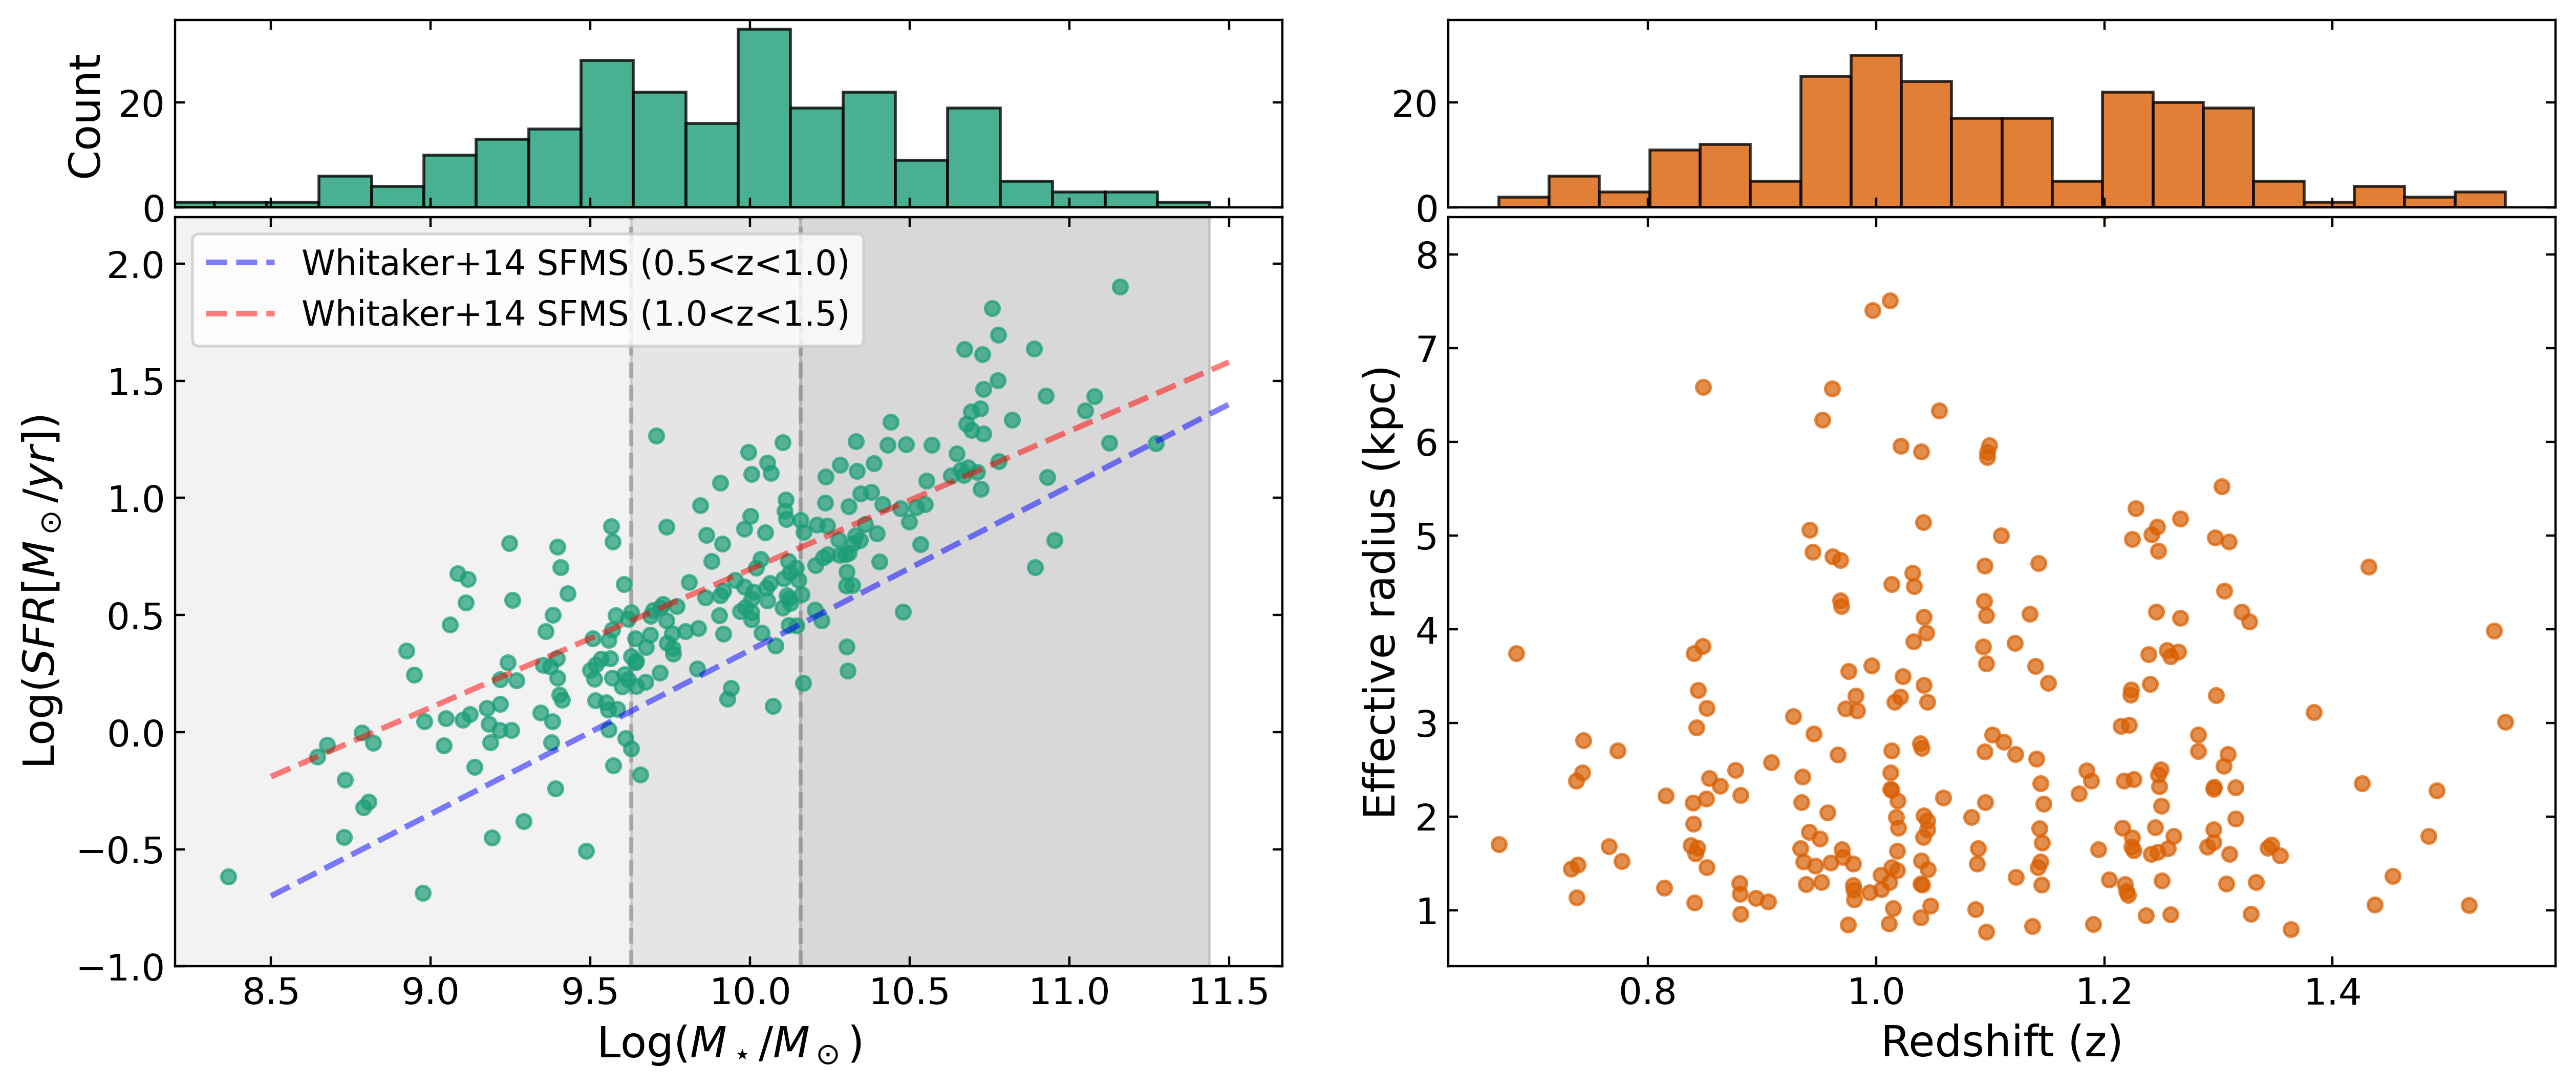

Median log(Mass/M_sun): 9.95
Median Redshift: 1.06


In [4]:
# Create figure and grid layout - smaller figure size
plt.figure(figsize=(15, 6), dpi=400)
# Grid layout: 2 rows, 2 columns, height ratio [histogram:scatter] = 1:4, width ratio 1:1
gs = GridSpec(2, 2, height_ratios=[1, 4], width_ratios=[1, 1], 
              hspace=0.02, wspace=0.15)  # Reduce hspace to bring x-axes closer

# Calculate log mass values (for shared x-axis)
mass_log = np.log10(obj_lis['mass'])

# Define mass bins for background shading
mass_bins = bins_m

# 1. Top left: Mass distribution histogram (shares x-axis with bottom left plot)
ax_hist_mass = plt.subplot(gs[0, 0])
ax_hist_mass.hist(mass_log, bins=20, color=color1, edgecolor='black', alpha=0.8)
ax_hist_mass.set_ylabel('Count', fontsize=15)  # Increased font size
# Hide x-axis labels (shares x-axis with main plot below)
ax_hist_mass.tick_params(axis='x', labelbottom=False, direction='in', which='both', 
                        top=True, right=True, left=True, bottom=True, labelsize=13)
ax_hist_mass.tick_params(axis='y', direction='in', which='both', 
                        top=True, right=True, left=True, bottom=True, labelsize=13)
#ax_hist_mass.set_yticklabels([label for label in ax_hist_mass.get_yticks() if label != 0])

# 2. Bottom left: SFR vs Mass scatter plot
ax_scatter1 = plt.subplot(gs[1, 0])

# Add background shading for different mass bins
y_min, y_max = ax_scatter1.get_ylim()
y_min, y_max = -2, 2  # Set appropriate y-limits for log(SFR)

# Add shaded regions for each mass bin with different gray levels
ax_scatter1.axvspan(mass_bins[0], mass_bins[1], color='grey', alpha=0.1, zorder=0)
ax_scatter1.axvspan(mass_bins[1], mass_bins[2], color='grey', alpha=0.2, zorder=0)
ax_scatter1.axvspan(mass_bins[2], mass_bins[3], color='grey', alpha=0.3, zorder=0)

# Add Whitaker+14 SFMS relations for different redshift ranges
# SFMS: log(SFR) = α(z) × (log M* - 10.5) + β(z)
mass_range = np.linspace(8.5, 11.5, 100)

# z=0.5-1.0: α = 0.70, β = 0.70
sfr_z05to1 = 0.70 * (mass_range - 10.5) + 0.70
ax_scatter1.plot(mass_range, sfr_z05to1, color='blue', linestyle='--', alpha=0.5,
                linewidth=2, label='Whitaker+14 SFMS (0.5<z<1.0)', zorder=3)

# z=1.0-1.5: α = 0.59, β = 0.99
sfr_z1to15 = 0.59 * (mass_range - 10.5) + 0.99
ax_scatter1.plot(mass_range, sfr_z1to15, color='red', linestyle='--', alpha=0.5,
                linewidth=2, label='Whitaker+14 SFMS (1.0<z<1.5)', zorder=3)

ax_scatter1.legend(fontsize=12, loc='upper left')
# Add vertical lines to separate mass bins
for m in mass_bins[1:-1]:  # Skip first and last bins
    ax_scatter1.axvline(m, color='grey', linestyle='--', alpha=0.5, zorder=1)

# Use single color instead of colormap
ax_scatter1.scatter(mass_log, np.log10(obj_lis['sfr']), 
                   s=25, alpha=0.7, color=color1, zorder=2)
ax_scatter1.set_xlabel('Log$\\left(M_\star / M_\odot \\right)$', fontsize=15)  # Increased font size
ax_scatter1.set_ylabel('Log$\\left(SFR [M_\odot / yr] \\right)$', fontsize=15)  # Increased font size
#now add whitaker SFMS diagramm

# Set y-limits
ax_scatter1.set_ylim(-1, y_max*1.1)
ax_scatter1.set_xlim(8.2, )

# Remove grid and title
ax_scatter1.tick_params(direction='in', which='both', top=True, right=True, 
                       left=True, bottom=True, labelsize=13)

# 3. Top right: Redshift distribution histogram
ax_hist_z = plt.subplot(gs[0, 1])
ax_hist_z.hist(obj_lis['z_MAP'], bins=20, color=color2, edgecolor='black', alpha=0.8)
#ax_hist_z.set_ylabel('Count', fontsize=15)
# Hide x-axis labels (shares x-axis with bottom right plot)
ax_hist_z.tick_params(axis='x', labelbottom=False, direction='in', which='both', 
                     top=True, right=True, left=True, bottom=True, labelsize=13)
ax_hist_z.tick_params(axis='y', direction='in', which='both', 
                     top=True, right=True, left=True, bottom=True, labelsize=13)

# 4. Bottom right: Mass vs Redshift scatter plot (axes swapped)
ax_scatter2 = plt.subplot(gs[1, 1])
# Note: axes are swapped - redshift on x-axis, mass on y-axis, using single color
ax_scatter2.scatter(obj_lis['z_MAP'], obj_lis['re']/0.1*obj_lis['pixel_length'], 
                   s=25, alpha=0.7, color=color2)

ax_scatter2.set_xlabel('Redshift (z)', fontsize=15)  # Increased font size
ax_scatter2.set_ylabel('Effective radius (kpc)', fontsize=15)  # Increased font size
# Remove grid
ax_scatter2.tick_params(direction='in', which='both', top=True, right=True, 
                       left=True, bottom=True, labelsize=13)
ax_scatter2.set_ylim(0.4,8.4)
# 5. Share x-axes
# Bottom left and top left share x-axis (log mass)
ax_hist_mass.sharex(ax_scatter1)
# Bottom right and top right share x-axis (redshift)
ax_hist_z.sharex(ax_scatter2)

# Ensure both histograms have the same y-axis range
hist1_ylim = ax_hist_mass.get_ylim()
hist2_ylim = ax_hist_z.get_ylim()
max_ylim = max(hist1_ylim[1], hist2_ylim[1])
ax_hist_mass.set_ylim(0, max_ylim)
ax_hist_z.set_ylim(0, max_ylim)

# Adjust layout and display
plt.tight_layout()
plt.savefig('output/sample_properties.png')
plt.show()

#print median mass and redshift for the whole sample
median_mass = np.median(np.log10(obj_lis['mass']))
median_redshift = np.median(obj_lis['z_MAP'])
print(f'Median log(Mass/M_sun): {median_mass:.2f}')
print(f'Median Redshift: {median_redshift:.2f}')

# plotting for Balmer decrement in kpc

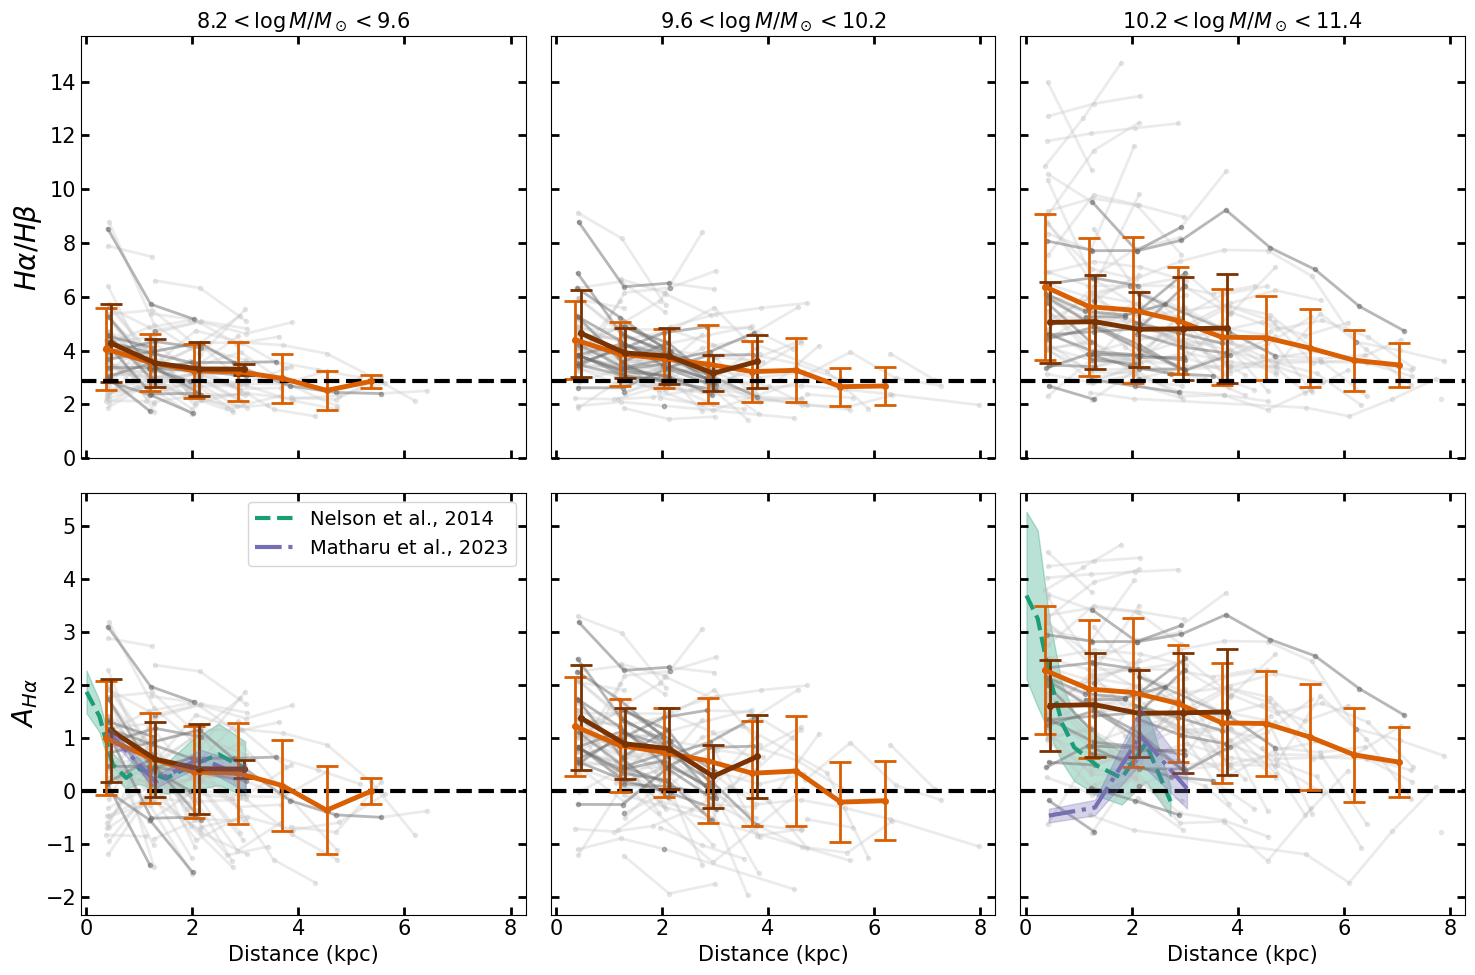

In [5]:
plt.rcParams.update({'font.size': 15})
fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey='row')  # 2 rows, 3 columns with shared axes
r_lim = 3*median_reff_kpc
#r_lim = 12

# top row plot mean ratio curve + individual profiles
for i in range(3):
    ax_top = axes[0, i]  # Top row positions: (0,0), (0,1), (0,2)
    ax_bottom = axes[1, i]  # Bottom row positions: (1,0), (1,1), (1,2)
    ax_top.tick_params(direction='in', which='both', top=True, right=True, width=2, length=6, labelsize=15)
    ax_bottom.tick_params(direction='in', which='both', top=True, right=True, width=2, length=6, labelsize=15)  # Set tick width and length
    
    for r, bd, alphas in zip(r_kpc_lis[i], balmer_kpc_all[i],alpha_values[i]):
        # line
        ax_top.plot(r, bd,linewidth=2, 
                    marker='o', markersize=3, 
                    color='silver', alpha=0.3)
    #high quality points
    for r, bd, alphas in zip(r_kpc_lis[i], balmer_kpc_all[i],alpha_values[i]):
        mask_for_hq = np.array(alphas)
        # highlight points with high S/N in both Ha and Hb
        ax_top.plot(np.array(r)[mask_for_hq], np.array(bd)[mask_for_hq], linewidth=2,
                       marker='.',markersize=6, alpha=0.4, color='dimgray')
                


    ax_top.errorbar(r_bin_kpc_lis-0.05, bd_kpc_lis[i],
                    yerr=std_kpc_lis[i], 
                    fmt='-', color=color2, alpha=1, 
                    linewidth=3.5, marker='o', markersize=4, 
                    elinewidth=2,capsize=8,capthick=2)
    
    #plot high sigma mean with error bars
    ax_top.errorbar(r_bin_kpc_lis+0.05, bd_kpc_lis_hsigma[i],
                    yerr=std_kpc_lis_hsigma[i], 
                    fmt='-', color=color4, alpha=1, 
                    linewidth=3.5, marker='o', markersize=4, 
                    elinewidth=2,capsize=8,capthick=2)

    # Common elements
    ax_top.axhline(2.86, 0, 7, linestyle='--', color='black',linewidth=3)
    ax_top.set_xlim(-0.1, r_lim)
    ax_top.set_ylim(0, 15.7)
    ax_top.set_title(bin_label_m[i], fontsize=15)
    if i == 0:
        ax_top.set_ylabel(r'$H\alpha/H\beta$', fontsize=20)
        
#------------------ bottom row plot attenuation curve + individual profiles------------------
    for r, bd, alphas in zip(r_kpc_lis[i], balmer_kpc_all[i],alpha_values[i]):
        # line
        ax_bottom.plot(r, calculate_attenuation_from_ratio(bd),linewidth=2, 
                    marker='o', markersize=3, 
                    color='silver', alpha=0.3)
    #high quality points
    for r, bd, alphas in zip(r_kpc_lis[i], balmer_kpc_all[i],alpha_values[i]):
        mask_for_hq = np.array(alphas)
        # highlight points with high S/N in both Ha and Hb
        ax_bottom.plot(np.array(r)[mask_for_hq], calculate_attenuation_from_ratio(np.array(bd)[mask_for_hq]), linewidth=2,
                       marker='.',markersize=6, alpha=0.4, color='dimgray')

# ----------------- Literature data -----------------
    # 3D-HST data
    r_theo1, balmer_theo1, balmer_err_theo1 = hst3d_result(['middle',None ,'high'][i])
    balmer_theo1 = calculate_attenuation_from_ratio(balmer_theo1)
    balmer_err_theo1 = calculate_attenuation_err(balmer_err_theo1)
    if i == 0:
        index = 1
    else:
        index = i
    ax_bottom.plot(r_theo1, balmer_theo1, marker=None, linestyle='--', linewidth=3,
                color=color1, label='Nelson et al., 2014')#f'3D-HST\nz~1.4\n{hst3d_label[index]}')
    ax_bottom.fill_between(r_theo1, 
                        balmer_theo1 - balmer_err_theo1,
                        balmer_theo1 + balmer_err_theo1,
                        color=color1, alpha=0.3)
    
    # JWST data
    r_theo2, balmer_theo2, balmer_err_theo2 = jwst_result(['middle', None, 'high'][i])
    balmer_theo2     = calculate_attenuation(balmer_theo2)
    balmer_err_theo2 = calculate_attenuation_err(balmer_err_theo2)
    ax_bottom.plot(r_theo2, balmer_theo2, marker=None, linestyle='-.',
                color=color3, linewidth=3, 
                label='Matharu et al., 2023')#f'JWST\nz:[1.0,1.7]\n{jwst_label[index]}')
    ax_bottom.fill_between(r_theo2, 
                        balmer_theo2 - balmer_err_theo2,
                        balmer_theo2 + balmer_err_theo2,
                        color=color3, alpha=0.3,zorder=1000)

    if i==0:
        ax_bottom.set_ylabel(r'$A_{H\alpha}$', fontsize=20)
        ax_bottom.legend(fontsize=14, loc='upper right')
    ax_bottom.axhline(0, linestyle='--', color='black',linewidth=3)
    # Only add x-axis label to bottom row middle column
    ax_bottom.set_xlabel('Distance (kpc)',fontsize=15)
    ax_bottom.set_xlim(-0.1, r_lim+0.2)
    #ax_bottom.set_ylim(-1.43, 5)
    
    
    ax_bottom.errorbar(r_bin_kpc_lis-0.05, calculate_attenuation_from_ratio(bd_kpc_lis[i]),
                    yerr=calculate_attenuation_err_from_ratio(bd_kpc_lis[i], std_kpc_lis[i]), 
                    #xerr= std_r_values,
                    fmt='-', color=color2, alpha=1, 
                    linewidth=3.5, marker='o', markersize=4, 
                    elinewidth=2,capsize=8,capthick=2)
    
    ax_bottom.errorbar(r_bin_kpc_lis+0.05, calculate_attenuation_from_ratio(bd_kpc_lis_hsigma[i]),
                    yerr=calculate_attenuation_err_from_ratio(bd_kpc_lis_hsigma[i], std_kpc_lis_hsigma[i]), 
                    #xerr= std_r_values,
                    fmt='-', color=color4, alpha=1, 
                    linewidth=3.5, marker='o', markersize=4, 
                    elinewidth=2,capsize=8,capthick=2)
    
# ============================== Final adjustments and saving ==============================
plt.tight_layout()  # Increase layout spacing
plt.savefig('output/kpc.png', dpi=300, bbox_inches='tight')
plt.show()


# plot radial profiles of dust attenuation in r/reff

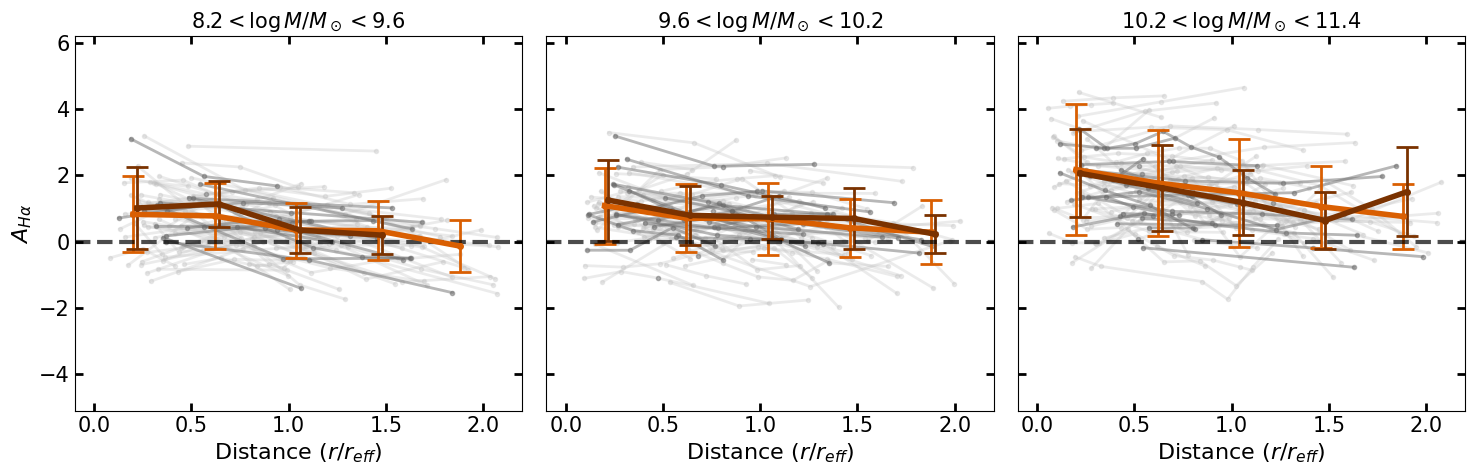

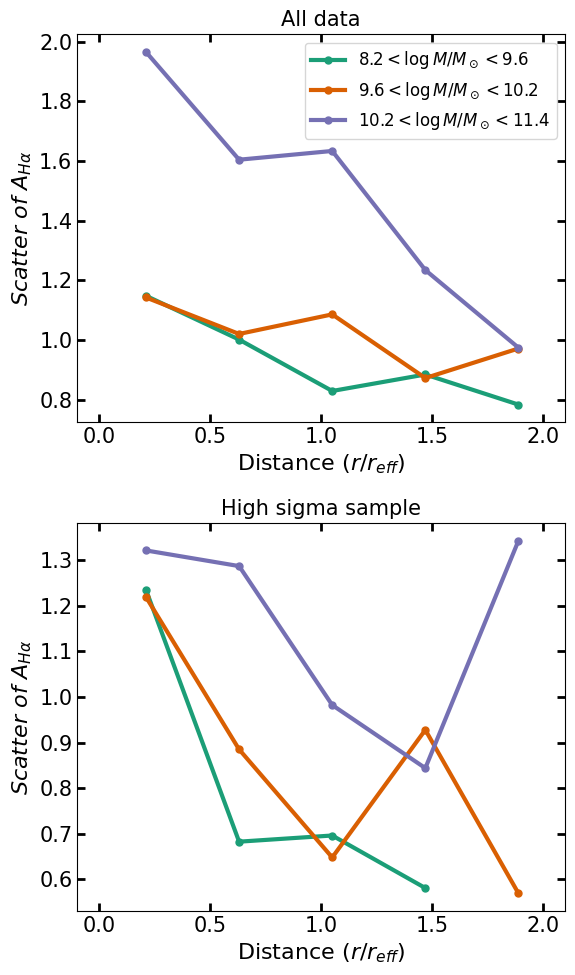

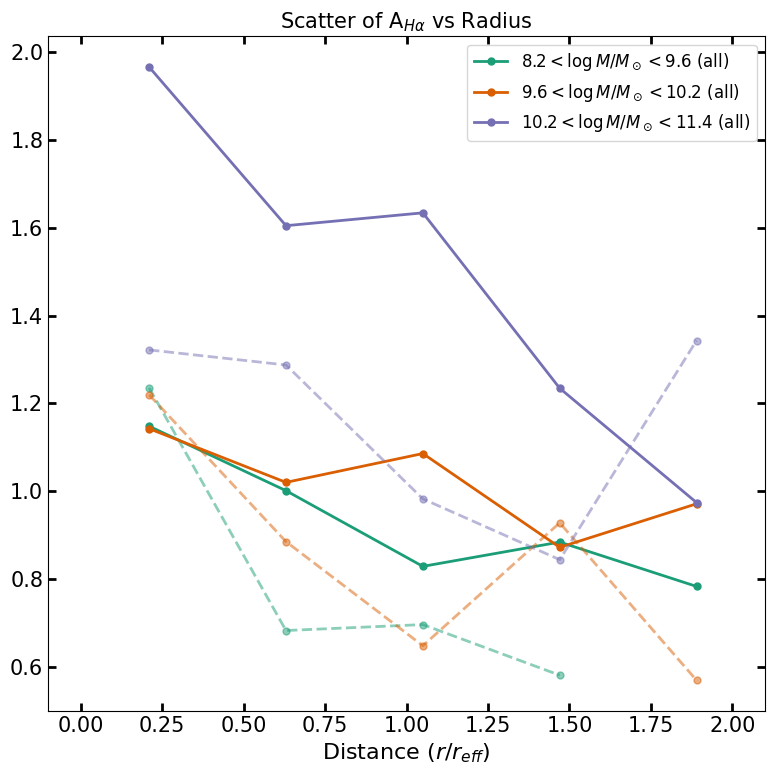

In [6]:

plt.rcParams.update({'font.size': 15})
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)  # 1 row, 3 columns with shared y-axis
r_lim = 2.1

for i in range(3):
    ax_re = axes[i]  # Positions: (0,0), (0,1), (0,2
    ax_re.tick_params(direction='in', which='both', top=True, right=True, width=2, length=6, labelsize=15)  # Set tick width, length, and label size
    for r, bd, alphas in zip(r_reff_lis[i], balmer_reff_all[i], alpha_values[i]):
        ax_re.plot(r, calculate_attenuation_from_ratio(bd),linewidth=2, 
                    marker='o', markersize=3, 
                    color='silver', alpha=0.3)
    for r, bd, alphas in zip(r_reff_lis[i], balmer_reff_all[i], alpha_values[i]):
        mask_for_hq = np.array(alphas)
        ax_re.plot(np.array(r)[mask_for_hq], calculate_attenuation_from_ratio(np.array(bd)[mask_for_hq]), linewidth=2,
                       marker='.',markersize=6, alpha=0.4, color='dimgray')
        
        
    ax_re.errorbar(r_bin_reff_lis-0.01, calculate_attenuation_from_ratio(bd_reff_lis[i]), 
                yerr=calculate_attenuation_err(std_reff_lis[i]),
                fmt='-', color=color2, alpha=1, linewidth=4,
                marker='o', markersize=4, label='Median A$_{H\\alpha}$', elinewidth=2,capsize=8,capthick=2)
    
    ax_re.errorbar(r_bin_reff_lis+0.01, calculate_attenuation_from_ratio(bd_reff_lis_hsigma[i]), 
                yerr=calculate_attenuation_err(std_reff_lis_hsigma[i]),
                fmt='-', color=color4, alpha=1, linewidth=4,
                marker='o', markersize=4, label='Median A$_{H\\alpha}$ (high S/N)', elinewidth=2,capsize=8,capthick=2)
    
    # Common elements
    ax_re.axhline(0, 0, r_lim, linestyle='--', color='black',linewidth=3, alpha=0.7)
    ax_re.set_xlim(-0.1, r_lim+0.1)
    ax_re.set_ylim(-5.1, 6.2)
    
    # Add mass bin labels
    #ax_re.text(0.95, 0.95, bin_label_m[i], transform=ax_re.transAxes, fontsize=15, verticalalignment='top', horizontalalignment='right')
    ax_re.set_title(bin_label_m[i], fontsize=15)
    # Axis labels and title
    if i == 0:
        ax_re.set_ylabel(r'$A_{H\alpha}$', fontsize=16)
    ax_re.set_xlabel('Distance ($r/r_{eff}$)',fontsize=16)

plt.tight_layout()  # Increase layout spacing
plt.savefig('output/re.png', dpi=300, bbox_inches='tight')
plt.show()

#then we plot the scatter as a function of radius
#then we plot the scatter as a function of radius
fig, axes = plt.subplots(2, 1, figsize=(6, 10))

# Left panel: All data
ax_left = axes[0]
ax_left.tick_params(direction='in', which='both', top=True, right=True, width=2, length=6, labelsize=15)
for i in range(3):
    ax_left.plot(r_bin_reff_lis, calculate_attenuation_err(std_reff_lis[i]), marker='o', linestyle='-', color=[color1,color2,color3][i], label=bin_label_m[i], linewidth=3, markersize=5)
ax_left.set_xlabel('Distance ($r/r_{eff}$)', fontsize=16)
ax_left.set_ylabel(r'$Scatter\ of\ A_{H\alpha}$', fontsize=16)
ax_left.set_xlim(-0.1, r_lim)
ax_left.legend(fontsize=12)
ax_left.set_title('All data', fontsize=15)

# Right panel: High quality data
ax_right = axes[1]
ax_right.tick_params(direction='in', which='both', top=True, right=True, width=2, length=6, labelsize=15)
for i in range(3):
    ax_right.plot(r_bin_reff_lis, calculate_attenuation_err(std_reff_lis_hsigma[i]), marker='o', linestyle='-', color=[color1,color2,color3][i], label=bin_label_m[i], linewidth=3, markersize=5)
ax_right.set_xlabel('Distance ($r/r_{eff}$)', fontsize=16)
ax_right.set_ylabel(r'$Scatter\ of\ A_{H\alpha}$', fontsize=16)
ax_right.set_xlim(-0.1, r_lim)
ax_right.set_title('High sigma sample', fontsize=15)

plt.tight_layout()
plt.savefig('output/scatter.png', bbox_inches='tight')
plt.show()

#try plotting both low and high quality data together with dotted and solid lines
fig, ax = plt.subplots(figsize=(8, 8))
ax.tick_params(direction='in', which='both', top=True, right=True, width=2, length=6, labelsize=15)
for i in range(3):
    ax.plot(r_bin_reff_lis, calculate_attenuation_err(std_reff_lis[i]), marker='o', linestyle='-', color=[color1,color2,color3][i], label=bin_label_m[i]+' (all)', linewidth=2, markersize=5)
    ax.plot(r_bin_reff_lis, calculate_attenuation_err(std_reff_lis_hsigma[i]), marker='o', linestyle='--', color=[color1,color2,color3][i], linewidth=2, markersize=5,alpha=0.5)
ax.set_xlabel('Distance ($r/r_{eff}$)', fontsize=16)
#ax.set_ylabel(r'$Scatter\ of\ A_{H\alpha}$', fontsize=16)
ax.set_xlim(-0.1, r_lim)
ax.legend(fontsize=12)
ax.set_title('Scatter of A$_{H\\alpha}$ vs Radius', fontsize=15)
plt.tight_layout()
plt.savefig('output/scatter_combined.png', bbox_inches='tight')
plt.show()

# plot the halpha surface brightness profiles and sfr surface density profiles

<>:86: SyntaxWarning: invalid escape sequence '\s'
<>:100: SyntaxWarning: invalid escape sequence '\s'
<>:86: SyntaxWarning: invalid escape sequence '\s'
<>:100: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_50784/3148491177.py:86: SyntaxWarning: invalid escape sequence '\s'
  label='High $\sigma$ dust corrected')
/tmp/ipykernel_50784/3148491177.py:100: SyntaxWarning: invalid escape sequence '\s'
  label='Linear fit (High $\sigma$ dust corrected)')
/tmp/ipykernel_50784/3148491177.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([tick for tick in ax.get_yticks()])
/tmp/ipykernel_50784/3148491177.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([tick for tick in ax.get_yticks()])
/tmp/ipykernel_50784/3148491177.py:56: UserWarning: set_ticklabels() should only be us

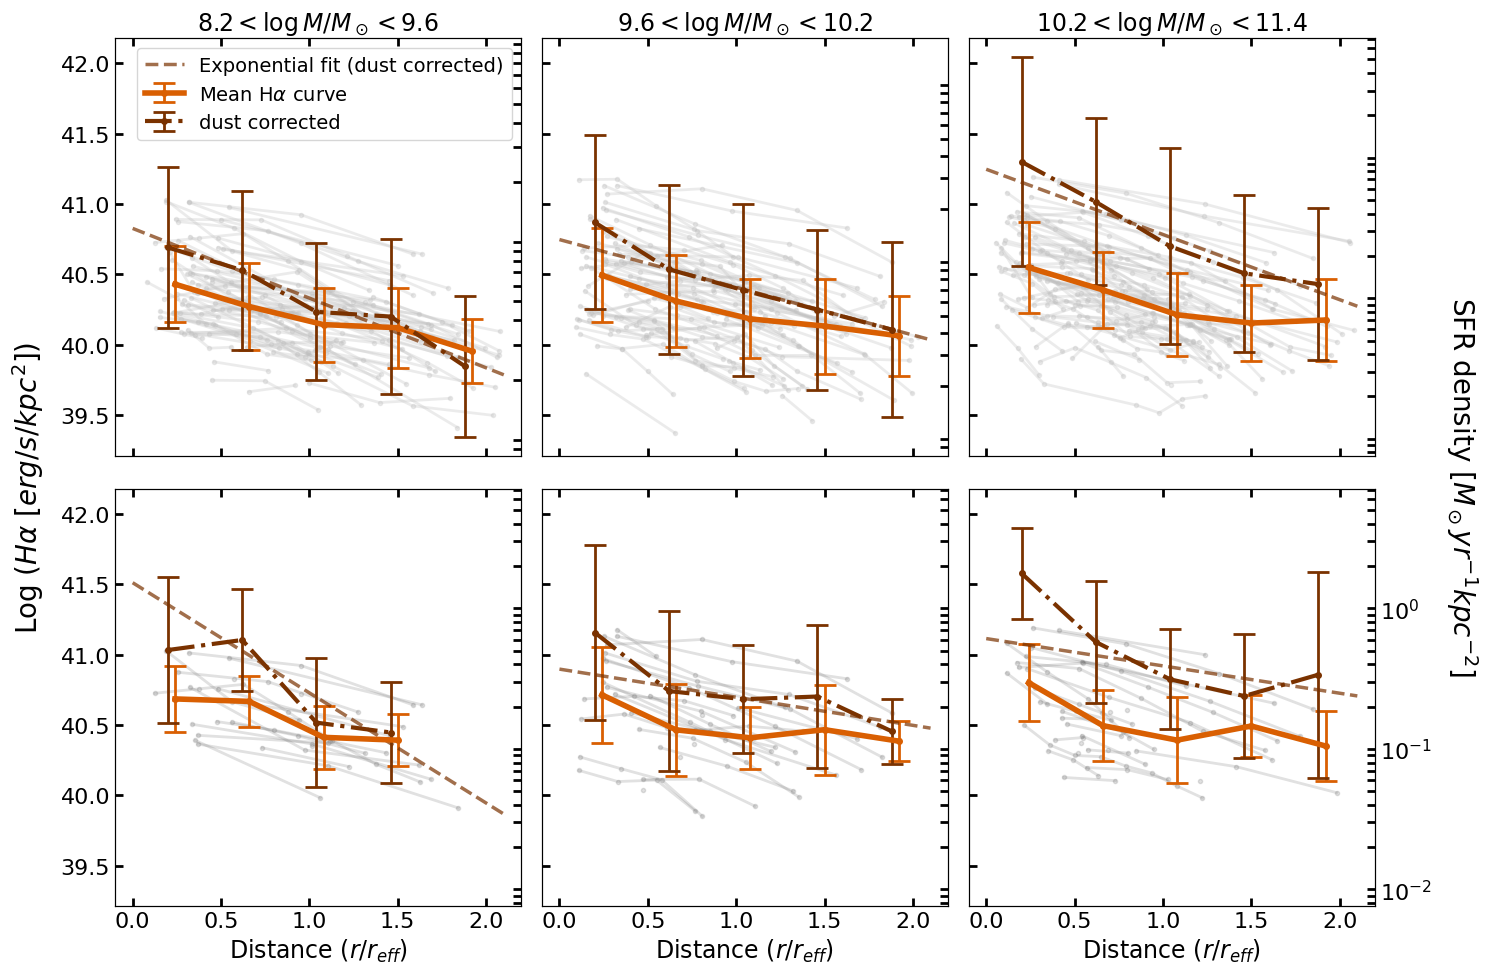

In [27]:
def exponential_func(r, A, B, C):
    return A * np.exp(-B * r) + C

def linear_func(r, m, c):
    return m * r + c

from scipy.optimize import curve_fit

# scale to sfr surface density
# note that the halpha flux in in the unit of 1e-17 erg/s/cm2/arcsec2
# so the sfr here refers to the sfr surface density in unit of Msun/yr/arcsec2
scale_to_sfr = 4.68 * 10**-42  # erg/s to Msun/yr conversion factor

fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharey=True)  # 2 rows, 3 columns with shared y-axis
plt.rcParams.update({'font.size': 15})
r_lim = 2.1

# ==================== Top row: all data ====================
for i in range(3):
    ax = axes[0, i]
    if i != 0:
        ax.set_yticklabels([])
    ax.tick_params(direction='in', which='both', top=True, right=True, width=2, length=6, labelsize=15)

    for r, ha, alphas in zip(r_reff_lis[i], ha_lis_all[i], alpha_values[i]):
        ax.plot(r, ha, linewidth=2,
                marker='o', markersize=3,
                color='silver', alpha=0.3)

    ax.errorbar(r_bin_ha_lis + 0.03, ha_mean_lis[i], yerr=std_ha_lis[i], fmt='-', color=color2, alpha=1,
                linewidth=4, marker='o', markersize=4, elinewidth=2, capsize=8, capthick=2,
                label=r'Mean H$\alpha$ curve')

    ax.errorbar(r_bin_ha_lis - 0.01, ha_corr_mean_lis[i], yerr=std_ha_corr_lis[i], fmt='-.', color=color4, alpha=1,
                linewidth=3, marker='o', markersize=4, elinewidth=2, capsize=8, capthick=2,
                label='dust corrected')

    fit = True
    if fit:
        # mask NaN values before fitting to avoid fitting failures
        x = r_bin_ha_lis[1:]
        y = np.array(ha_corr_mean_lis[i][1:])
        valid = ~np.isnan(y)
        if np.sum(valid) >= 2:
            popt, pcov = curve_fit(linear_func, x[valid], y[valid], absolute_sigma=True)
            r_fit = np.linspace(0, r_lim, 100)
            ha_fit = linear_func(r_fit, *popt)
            ax.plot(r_fit, ha_fit, linestyle='--', color=color4, alpha=0.7, linewidth=2.5,
                    label='Exponential fit (dust corrected)')

    ax.set_title(bin_label_m[i], fontsize=17)
    if i == 0:
        ax.legend(loc='upper right', fontsize=14)

    ax.set_xlim(-0.1, r_lim + 0.1)
    ax.set_yticklabels([tick for tick in ax.get_yticks()])
    ax.tick_params(labelbottom=False)  # Hide x-axis labels for top row
    ax_var = ax.twinx()

    ymin, ymax = ax.get_ylim()
    ax_var.set_ylim(10**ymin * scale_to_sfr, 10**ymax * scale_to_sfr)
    ax_var.set_yscale('log')

    ax.tick_params(direction='in', which='both', top=True, right=False, width=2, length=6, labelsize=16)
    ax_var.tick_params(direction='in', which='both', top=False, right=True, width=2, length=6, labelsize=16)
    ax_var.set_yticklabels([])  # Hide right y-axis labels for top row

# ==================== Bottom row: high sigma data ====================
for i in range(3):
    ax = axes[1, i]
    if i != 0:
        ax.set_yticklabels([])
    ax.tick_params(direction='in', which='both', top=True, right=True, width=2, length=6, labelsize=15)

    for r, ha, alphas in zip(r_reff_lis[i], ha_lis_all[i], alpha_values[i]):
        mask_for_hq = np.array(alphas)
        ax.plot(np.array(r)[mask_for_hq], np.array(ha)[mask_for_hq], linewidth=2,
                marker='.', markersize=6, alpha=0.2, color='dimgray')

    ax.errorbar(r_bin_ha_lis + 0.03, ha_mean_lis_hsigma[i], yerr=std_ha_lis_hsigma[i], fmt='-', color=color2, alpha=1,
                linewidth=4, marker='o', markersize=4, elinewidth=2, capsize=8, capthick=2,
                label=r'High $\sigma$ H$\alpha$')

    ax.errorbar(r_bin_ha_lis - 0.01, ha_corr_mean_lis_hsigma[i], yerr=std_ha_corr_lis_hsigma[i], fmt='-.', color=color4, alpha=1,
                linewidth=3, marker='o', markersize=4, elinewidth=2, capsize=8, capthick=2,
                label='High $\sigma$ dust corrected')

    fit = True
    if fit:
        # mask all NaN values before fitting
        x = r_bin_ha_lis[1:]
        y = np.array(ha_corr_mean_lis_hsigma[i][1:])
        yerr = np.array(std_ha_corr_lis_hsigma[i][1:])
        mask = ~np.isnan(y) & ~np.isnan(yerr)
        if np.sum(mask) >= 2:
            popt, pcov = curve_fit(linear_func, x[mask], y[mask], absolute_sigma=True)
            r_fit = np.linspace(0, r_lim, 100)
            ha_fit = linear_func(r_fit, *popt)
            ax.plot(r_fit, ha_fit, linestyle='--', color=color4, alpha=0.7, linewidth=2.5,
                    label='Linear fit (High $\sigma$ dust corrected)')

    #if i == 0:
    #    ax.legend(loc='upper right', fontsize=14)

    ax.set_xlabel('Distance $(r/r_{eff})$', fontsize=17)
    ax.set_xlim(-0.1, r_lim + 0.1)
    ax.set_yticklabels([tick for tick in ax.get_yticks()])
    ax_var = ax.twinx()

    ymin, ymax = ax.get_ylim()
    ax_var.set_ylim(10**ymin * scale_to_sfr, 10**ymax * scale_to_sfr)
    ax_var.set_yscale('log')

    ax.tick_params(direction='in', which='both', top=True, right=False, width=2, length=6, labelsize=16)
    ax_var.tick_params(direction='in', which='both', top=False, right=True, width=2, length=6, labelsize=16)
    if i != 2:
        ax_var.set_yticklabels([])

# Display the plot first with tight_layout
plt.tight_layout()
# Then adjust spacing between panels to make them more compact
plt.subplots_adjust(left=0.08, right=0.92, wspace=0.05, hspace=0.08)  # Reduced hspace for tighter vertical spacing
# Add common y-axis labels using fig.text
fig.text(0.01, 0.5, r"Log ($H\alpha$ [$erg/s/kpc^2$])", va='center', rotation='vertical', fontsize=20)
fig.text(0.99, 0.5, r'SFR density [$M_\odot yr^{-1} kpc^{-2}$]', va='center', ha='right', rotation=-90, fontsize=20)
plt.savefig('output/ha_re.png', dpi=300, bbox_inches='tight')
plt.show()